# Pipeline Deep Learning — PetFinder Adoption Prediction
**Grupo 8 — Maestria en Ciencia de Datos — Laboratorio 2**

---

## Descripcion

Este notebook implementa un pipeline de clasificacion de imagenes basado en Transfer Learning para predecir la variable `AdoptionSpeed` (clases ordinales 0 a 4) del dataset PetFinder.my. La arquitectura base es ResNet50 pre-entrenada en ImageNet con fine-tuning sobre el conjunto de entrenamiento.

La metrica de evaluacion es el **Quadratic Weighted Kappa (QWK)**, definida como:

```
QWK = 1 - (sum_i sum_j W_ij O_ij) / (sum_i sum_j W_ij E_ij)
```

donde `W_ij = (i-j)^2 / (N-1)^2` es la matriz de pesos cuadraticos, `O_ij` la matriz de confusion observada y `E_ij` la esperada bajo independencia. Esta metrica penaliza errores de forma proporcional al cuadrado de la distancia ordinal entre clases.

La busqueda de hiperparametros se realiza mediante OPTUNA con el estimador TPE (Tree-structured Parzen Estimator) y poda de trials via MedianPruner.

---

## Etapas

| Etapa | Descripcion |
|-------|-------------|
| 1 | Split estratificado 80/20 y organizacion de imagenes por clase en disco |
| 2 | Construccion de DataLoaders con augmentacion AutoAugment y Cutout |
| 3 | Carga de ResNet50 con pesos ImageNet y adaptacion de la capa de salida a 5 clases |
| 4 | Entrenamiento con SGD, scheduler ReduceLROnPlateau y early stopping por QWK |
| 5 | Busqueda bayesiana de hiperparametros con OPTUNA (ejecucion opcional) |
| 6 | Generacion de predicciones de validacion con PetID para ensamble externo |

---

## Prerequisitos

1. Activar GPU en Colab: T4 GPU.
2. Estructura de carpetas requerida en Google Drive:

```
Mi unidad/
    PETFINDER_GRUPO8_R10/              <- raiz del proyecto (DRIVE_BASE en Celda 3)
      input/
        petfinder-adoption-prediction/
          train/
            train.csv
            train_images/
      Imagenes/                        <- subir este notebook aqui
        work/                          <- se crea automaticamente en la primera ejecucion
```

El directorio `work/` se crea automaticamente en la primera ejecucion.

3. Ejecutar las celdas en orden secuencial.

---

## Variables de control (Celda 3)

| Variable | Descripcion |
|----------|-------------|
| `RUN_OPTUNA = False` | Carga hiperparametros desde `optuna_best_params.json` si existe; usa defaults en caso contrario |
| `RUN_OPTUNA = True` | Ejecuta la busqueda bayesiana completa. |
| `IGNORE_OPTUNA = True` | Ignora el archivo JSON y usa los valores default hardcodeados |
| `SKIP_PREP = True` | Omite la copia de imagenes; util cuando la estructura de carpetas ya fue creada en una ejecucion anterior |

---
## Celda 1 — Instalacion de dependencias

`optuna` es la unica dependencia no incluida en el entorno base de Colab.

In [23]:
# CELDA 1 — Instalar dependencias
!pip install optuna --quiet
print('Dependencias instaladas.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.1 MB/s eta 0:00:00
Dependencias instaladas.


---
## Celda 2 — Montaje de Google Drive



In [2]:
# CELDA 2 — Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')
print('Drive montado en /content/drive')

Mounted at /content/drive
Drive montado en /content/drive


---
## Celda 3 — Configuracion central

Esta celda concentra todos los parametros del pipeline. Es la unica seccion que requiere modificacion entre ejecuciones.

### Mejoras implementadas respecto a la version anterior

| N | Cambio | Valor | Fundamento tecnico |
|---|--------|-------|--------------------|
| 1 | Resolucion de entrada | IMAGE_SIZE = 224 | Resolucion nativa del backbone ResNet50 pre-entrenado en ImageNet. El uso de 299 px en versiones anteriores introducia un upscaling sin ganancia de informacion real |
| 2 | Funcion de perdida ponderada | CrossEntropyLoss(weight=w_c) | La Clase 0 representa el 2.7% del dataset (307 de 11,721 imagenes de train). Sin ponderacion, el gradiente de la loss esta dominado por las clases mayoritarias y el modelo converge a ignorar la clase minoritaria |
| 3 | Rango de epochs en OPTUNA | suggest_int('epochs', 5, 15) | El rango original (3 a 7) resultaba insuficiente para convergencia con learning rates en el extremo bajo del espacio de busqueda |
| 4 | Correccion del divisor de loss | n_procesados por batch | El divisor previo era len(train_ds) = 11,721, pero el DataLoader procesa 11,994 registros del CSV porque algunos animales tienen multiple imagenes. El error sistematico era de aproximadamente 2.3% |
| 5 | Piso de learning rate en OPTUNA | suggest_float('lr', 1e-4, 0.1) | Con lr menor a 1e-4 y SGD, la red no actualiza los pesos de forma significativa en el rango de epochs disponible, colapsando a QWK = 0.0. Verificado empiricamente en los trials 4 y 6 del estudio ResNet50_PetFinder_v2 |

### Nota sobre WeightedRandomSampler

Se evaluo la combinacion de `WeightedRandomSampler` en el DataLoader junto con `CrossEntropyLoss(weight=...)`. La doble ponderacion del desbalance de clases produjo inestabilidad en el entrenamiento cuando el learning rate era bajo, resultando en colapso del modelo con QWK = 0.0. Se adopto como criterio de diseno usar un unico mecanismo de correccion del desbalance: la funcion de perdida ponderada.

In [3]:
# CELDA 3 — Configuracion de rutas y parametros
# MODIFICAR SOLO ESTA SECCION SI ES NECESARIO

# Ruta base en Drive (ajustar si tu carpeta tiene otro nombre)
DRIVE_BASE = '/content/drive/MyDrive/PETFINDER_GRUPO8_R10'

# Modo de ejecucion
RUN_OPTUNA    = True  # True = busca hiperparametros nuevos (--run-optuna)
IGNORE_OPTUNA = False  # True = ignora JSON y usa defaults hardcodeados (--ignore-optuna)
SKIP_PREP     = False  # True = omite copia de imagenes (--skip-prep)

# Hiperparametros fijos
IMAGE_SIZE  = 224
BATCH_SIZE  = 64
TEST_SIZE   = 0.20
SEED        = 42
N_CLASSES   = 5
CLASS_NAMES = ['0', '1', '2', '3', '4']
MODEL_NAME  = 'ResNet50_PetFinder_v2'
N_TRIALS    = 10

# Defaults (usados si IGNORE_OPTUNA=True o no hay JSON y RUN_OPTUNA=False)
LR_DEFAULT       = 0.001
MOMENTUM_DEFAULT = 0.9
EPOCHS_DEFAULT   = 7
PATIENCE_DEFAULT = 3

# Estadisticas ImageNet (NO modificar)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print('Configuracion cargada.')
print(f'  Drive base    : {DRIVE_BASE}')
print(f'  RUN_OPTUNA    : {RUN_OPTUNA}')
print(f'  IGNORE_OPTUNA : {IGNORE_OPTUNA}')
print(f'  SKIP_PREP     : {SKIP_PREP}')
print(f'  IMAGE_SIZE    : {IMAGE_SIZE} | BATCH_SIZE: {BATCH_SIZE} | SEED: {SEED}')

Configuracion cargada.
  Drive base    : /content/drive/MyDrive/PETFINDER_GRUPO8_R10
  RUN_OPTUNA    : True
  IGNORE_OPTUNA : False
  SKIP_PREP     : False
  IMAGE_SIZE    : 224 | BATCH_SIZE: 64 | SEED: 42


---
## Celda 4 — Importaciones y estructura de directorios

Carga las dependencias del pipeline y define la estructura de rutas relativa a la carpeta base en Drive. Se detecta el dispositivo de computo disponible (`cuda` o `cpu`). Se usa `tqdm.notebook` en lugar de `tqdm` para compatibilidad con el renderizado de widgets en Colab. Los directorios del workspace se crean automaticamente si no existen.

In [24]:
# CELDA 4 — Importaciones y rutas
import sys, os, copy, time, json, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score
from joblib import dump
from tqdm.notebook import tqdm   # version notebook para barras de progreso en Colab

try:
    import optuna
    from optuna.pruners import MedianPruner
    OPTUNA_AVAILABLE = True
    print('OPTUNA disponible:', optuna.__version__)
except ImportError:
    OPTUNA_AVAILABLE = False
    print('ADVERTENCIA: OPTUNA no disponible. Ejecutar celda 1.')

# Rutas principales
ROOT          = Path(DRIVE_BASE)
INPUT_DIR     = ROOT / 'input' / 'petfinder-adoption-prediction'
TRAIN_CSV     = INPUT_DIR / 'train' / 'train.csv'
IMAGES_DIR    = INPUT_DIR / 'train' / 'train_images'
WORK_DIR      = ROOT / 'Imagenes' / 'work'
TRAIN_IMG_DIR = WORK_DIR / 'train_images_classes'
VAL_IMG_DIR   = WORK_DIR / 'val_images_classes'
ARTIFACTS_DIR = WORK_DIR / 'optuna_artifacts'
TEMP_DIR      = WORK_DIR / 'optuna_temp_artifacts'
RESULTS_DIR   = WORK_DIR / 'resultados'
OPTUNA_DB     = f"sqlite:///{WORK_DIR / 'optuna_deep.sqlite3'}"

# Crear directorios necesarios
for _d in [WORK_DIR, TRAIN_IMG_DIR, VAL_IMG_DIR, ARTIFACTS_DIR, TEMP_DIR, RESULTS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)
for _clase in CLASS_NAMES:
    (TRAIN_IMG_DIR / _clase).mkdir(exist_ok=True)
    (VAL_IMG_DIR   / _clase).mkdir(exist_ok=True)

# Dispositivo
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print('\nRutas:')
print(f'  CSV    : {TRAIN_CSV}')
print(f'  Imagenes: {IMAGES_DIR}')
print(f'  Work   : {WORK_DIR}')

OPTUNA disponible: 4.8.0
Dispositivo: cuda
  GPU: NVIDIA A100-SXM4-80GB
  VRAM: 85.1 GB

Rutas:
  CSV    : /content/drive/MyDrive/PETFINDER_GRUPO8_R10/input/petfinder-adoption-prediction/train/train.csv
  Imagenes: /content/drive/MyDrive/PETFINDER_GRUPO8_R10/input/petfinder-adoption-prediction/train/train_images
  Work   : /content/drive/MyDrive/PETFINDER_GRUPO8_R10/Imagenes/work


## Celda 5 — Exploración de disponibilidad de imágenes

Analiza la cobertura de imágenes en el dataset antes de ejecutar el pipeline de entrenamiento. Determina cuántas mascotas tienen imagen principal disponible (`PetID-1.jpg`), cuántas carecen de imagen, y cómo se distribuye esa cobertura por clase de adopción.

**Impacto en el pipeline.** El modelo ResNet50 solo puede procesar mascotas que cuentan con al menos una imagen en disco. Los registros sin imagen quedan fuera del pipeline visual y son cubiertos exclusivamente por el modelo tabular (LightGBM) en la etapa de ensamble. Solo se utiliza la imagen principal (`-1.jpg`) por mascota; las fotos adicionales no se incorporan.

In [9]:
# CELDA 5 EDA: Exploración de imágenes disponibles
print('=' * 70)
print('EXPLORACIÓN DE DATOS — IMÁGENES')
print('=' * 70)

df = pd.read_csv(TRAIN_CSV)

# ── 1. Leer imágenes disponibles UNA SOLA VEZ (evita OSError en Drive) ──
print('\nCargando listado de imágenes desde Drive (puede tardar unos segundos)...')
imagenes_disponibles = {f.stem for f in IMAGES_DIR.glob('*.jpg')}
total_imagenes = len(imagenes_disponibles)

if total_imagenes == 0:
    raise RuntimeError(
        f'No se encontraron imágenes en {IMAGES_DIR}\n'
        f'Verificá que Drive esté bien montado y la carpeta exista.\n'
        f'Solución: ejecutá la Celda 2 (montaje Drive) y reintentá.'
    )

print(f'\nTotal registros en train.csv        : {len(df):,}')
print(f'Total archivos .jpg en train_images/: {total_imagenes:,}')

# ── 2. ¿Cuántas mascotas tienen foto principal? (lookup en set, sin Drive) ──
df['tiene_foto_1'] = df['PetID'].apply(
    lambda pid: f'{pid}-1' in imagenes_disponibles   # ← set lookup, no .exists()
)
con_foto = df['tiene_foto_1'].sum()
sin_foto = (~df['tiene_foto_1']).sum()

print(f'\nMascotas con foto principal (-1.jpg): {con_foto:,} ({con_foto/len(df)*100:.1f}%)')
print(f'Mascotas sin foto                   : {sin_foto:,} ({sin_foto/len(df)*100:.1f}%)')

# ── 3. Distribución de cantidad de fotos por mascota ─────────────────────
def contar_fotos(pet_id):
    return sum(1 for i in range(1, 30) if f'{pet_id}-{i}' in imagenes_disponibles)

print('\nContando fotos por mascota...')
df['n_fotos'] = df['PetID'].apply(contar_fotos)

print('\nDistribución de fotos por mascota:')
dist = df['n_fotos'].value_counts().sort_index()
for n_fotos, count in dist.items():
    barra = '█' * min(int(count / len(df) * 100), 40)
    print(f'  {n_fotos:>2} foto(s): {count:>5} mascotas ({count/len(df)*100:5.1f}%)  {barra}')

# ── 4. Fotos disponibles vs AdoptionSpeed ────────────────────────────────
print(f'\nRelación foto / AdoptionSpeed:')
print(f'{"Clase":<8} {"Total":>8} {"Con foto":>10} {"Sin foto":>10} {"% con foto":>12}')
print('-' * 52)
for clase in sorted(df['AdoptionSpeed'].unique()):
    sub    = df[df['AdoptionSpeed'] == clase]
    c_foto = sub['tiene_foto_1'].sum()
    s_foto = (~sub['tiene_foto_1']).sum()
    pct    = c_foto / len(sub) * 100
    print(f'  {clase:<6} {len(sub):>8,} {c_foto:>10,} {s_foto:>10,} {pct:>11.1f}%')

# ── 5. Impacto en el pipeline ─────────────────────────────────────────────
print(f'\nImpacto en el pipeline de imágenes:')
print(f'  El modelo ResNet50 solo procesa mascotas con foto principal (-1.jpg).')
print(f'  Las {sin_foto:,} mascotas sin foto ({sin_foto/len(df)*100:.1f}%) quedan fuera del pipeline visual.')
print(f'  El modelo tabular (LightGBM) cubre el 100% de los registros.')
print(f'  En el ensamble, las mascotas sin foto reciben peso 0 de ResNet50.')
print(f'  Solo se usa la imagen -1.jpg por mascota (foto principal del anuncio).')
print(f'  Las mascotas con múltiples fotos ({(df["n_fotos"] > 1).sum():,}) usan solo la primera.')

EXPLORACIÓN DE DATOS — IMÁGENES

Cargando listado de imágenes desde Drive (puede tardar unos segundos)...

Total registros en train.csv        : 14,993
Total archivos .jpg en train_images/: 58,311

Mascotas con foto principal (-1.jpg): 14,652 (97.7%)
Mascotas sin foto                   : 341 (2.3%)

Contando fotos por mascota...

Distribución de fotos por mascota:
   0 foto(s):   341 mascotas (  2.3%)  ██
   1 foto(s):  3075 mascotas ( 20.5%)  ████████████████████
   2 foto(s):  2518 mascotas ( 16.8%)  ████████████████
   3 foto(s):  2511 mascotas ( 16.7%)  ████████████████
   4 foto(s):  1881 mascotas ( 12.5%)  ████████████
   5 foto(s):  2147 mascotas ( 14.3%)  ██████████████
   6 foto(s):   621 mascotas (  4.1%)  ████
   7 foto(s):   432 mascotas (  2.9%)  ██
   8 foto(s):   314 mascotas (  2.1%)  ██
   9 foto(s):   231 mascotas (  1.5%)  █
  10 foto(s):   190 mascotas (  1.3%)  █
  11 foto(s):   184 mascotas (  1.2%)  █
  12 foto(s):    97 mascotas (  0.6%)  
  13 foto(s):    86 ma

---
## Celda 6 — Modulos de augmentacion de imagen

### AutoAugment — ImageNetPolicy

Implementacion de la politica de augmentacion aprendida sobre ImageNet descripta en Cubuk et al. (2019).

Referencia: Cubuk, E. D., Zoph, B., Mane, D., Vasudevan, V., y Le, Q. V. (2019). AutoAugment: Learning Augmentation Strategies from Data. CVPR 2019.

### Cutout

Tecnica de regularizacion que enmascara una region cuadrada de tamano fijo en la representacion tensorial de la imagen, forzando al modelo a aprender representaciones distribuidas y reduciendo la dependencia de regiones locales especificas.

Referencia: DeVries, T., y Taylor, G. W. (2017). Improved Regularization of Convolutional Neural Networks with Cutout. arXiv:1708.04552.

In [5]:
# CELDA 6— Modulos de augmentacion (autoaugment + cutout)

import random
from PIL import Image, ImageEnhance, ImageOps

# ---------- ops.py ----------
class ShearX:
    def __init__(self, fillcolor=(128,128,128)): self.fillcolor = fillcolor
    def __call__(self, x, magnitude):
        return x.transform(x.size, Image.AFFINE,
            (1, magnitude*random.choice([-1,1]), 0, 0, 1, 0),
            Image.BICUBIC, fillcolor=self.fillcolor)

class ShearY:
    def __init__(self, fillcolor=(128,128,128)): self.fillcolor = fillcolor
    def __call__(self, x, magnitude):
        return x.transform(x.size, Image.AFFINE,
            (1, 0, 0, magnitude*random.choice([-1,1]), 1, 0),
            Image.BICUBIC, fillcolor=self.fillcolor)

class TranslateX:
    def __init__(self, fillcolor=(128,128,128)): self.fillcolor = fillcolor
    def __call__(self, x, magnitude):
        return x.transform(x.size, Image.AFFINE,
            (1, 0, magnitude*x.size[0]*random.choice([-1,1]), 0, 1, 0),
            fillcolor=self.fillcolor)

class TranslateY:
    def __init__(self, fillcolor=(128,128,128)): self.fillcolor = fillcolor
    def __call__(self, x, magnitude):
        return x.transform(x.size, Image.AFFINE,
            (1, 0, 0, 0, 1, magnitude*x.size[1]*random.choice([-1,1])),
            fillcolor=self.fillcolor)

class Rotate:
    def __call__(self, x, magnitude):
        rot = x.convert('RGBA').rotate(magnitude*random.choice([-1,1]))
        return Image.composite(rot, Image.new('RGBA', rot.size, (128,)*4), rot).convert(x.mode)

class Color:
    def __call__(self, x, magnitude): return ImageEnhance.Color(x).enhance(1+magnitude*random.choice([-1,1]))
class Posterize:
    def __call__(self, x, magnitude): return ImageOps.posterize(x, int(magnitude))
class Solarize:
    def __call__(self, x, magnitude): return ImageOps.solarize(x, int(magnitude))
class Contrast:
    def __call__(self, x, magnitude): return ImageEnhance.Contrast(x).enhance(1+magnitude*random.choice([-1,1]))
class Sharpness:
    def __call__(self, x, magnitude): return ImageEnhance.Sharpness(x).enhance(1+magnitude*random.choice([-1,1]))
class Brightness:
    def __call__(self, x, magnitude): return ImageEnhance.Brightness(x).enhance(1+magnitude*random.choice([-1,1]))
class AutoContrast:
    def __call__(self, x, magnitude): return ImageOps.autocontrast(x)
class Equalize:
    def __call__(self, x, magnitude): return ImageOps.equalize(x)
class Invert:
    def __call__(self, x, magnitude): return ImageOps.invert(x)

# ---------- autoaugment.py ----------
class SubPolicy:
    def __init__(self, p1, op1, mag1, p2, op2, mag2, fillcolor=(128,128,128)):
        ranges = {
            'shearX': np.linspace(0,0.3,10), 'shearY': np.linspace(0,0.3,10),
            'translateX': np.linspace(0,150/331,10), 'translateY': np.linspace(0,150/331,10),
            'rotate': np.linspace(0,30,10), 'color': np.linspace(0.0,0.9,10),
            'posterize': np.round(np.linspace(8,4,10),0).astype(int),
            'solarize': np.linspace(256,0,10), 'contrast': np.linspace(0.0,0.9,10),
            'sharpness': np.linspace(0.0,0.9,10), 'brightness': np.linspace(0.0,0.9,10),
            'autocontrast': [0]*10, 'equalize': [0]*10, 'invert': [0]*10
        }
        func = {
            'shearX': ShearX(fillcolor), 'shearY': ShearY(fillcolor),
            'translateX': TranslateX(fillcolor), 'translateY': TranslateY(fillcolor),
            'rotate': Rotate(), 'color': Color(), 'posterize': Posterize(),
            'solarize': Solarize(), 'contrast': Contrast(), 'sharpness': Sharpness(),
            'brightness': Brightness(), 'autocontrast': AutoContrast(),
            'equalize': Equalize(), 'invert': Invert()
        }
        self.p1 = p1; self.op1 = func[op1]; self.mag1 = ranges[op1][mag1]
        self.p2 = p2; self.op2 = func[op2]; self.mag2 = ranges[op2][mag2]
    def __call__(self, img):
        if random.random() < self.p1: img = self.op1(img, self.mag1)
        if random.random() < self.p2: img = self.op2(img, self.mag2)
        return img

class ImageNetPolicy:
    def __init__(self, fillcolor=(128,128,128)):
        self.policies = [
            SubPolicy(0.4,'posterize',8,0.6,'rotate',9,fillcolor),
            SubPolicy(0.6,'solarize',5,0.6,'autocontrast',5,fillcolor),
            SubPolicy(0.8,'equalize',8,0.6,'equalize',3,fillcolor),
            SubPolicy(0.6,'posterize',7,0.6,'posterize',6,fillcolor),
            SubPolicy(0.4,'equalize',7,0.2,'solarize',4,fillcolor),
            SubPolicy(0.4,'equalize',4,0.8,'rotate',8,fillcolor),
            SubPolicy(0.6,'solarize',3,0.6,'equalize',7,fillcolor),
            SubPolicy(0.8,'posterize',5,1.0,'equalize',2,fillcolor),
            SubPolicy(0.2,'rotate',3,0.6,'solarize',8,fillcolor),
            SubPolicy(0.6,'equalize',8,0.4,'posterize',6,fillcolor),
            SubPolicy(0.8,'rotate',8,0.4,'color',0,fillcolor),
            SubPolicy(0.4,'rotate',9,0.6,'equalize',2,fillcolor),
            SubPolicy(0.0,'equalize',7,0.8,'equalize',8,fillcolor),
            SubPolicy(0.6,'invert',4,1.0,'equalize',8,fillcolor),
            SubPolicy(0.6,'color',4,1.0,'contrast',8,fillcolor),
            SubPolicy(0.8,'rotate',8,1.0,'color',2,fillcolor),
            SubPolicy(0.8,'color',8,0.8,'solarize',7,fillcolor),
            SubPolicy(0.4,'sharpness',7,0.6,'invert',8,fillcolor),
            SubPolicy(0.6,'shearX',5,1.0,'equalize',9,fillcolor),
            SubPolicy(0.4,'color',0,0.6,'equalize',3,fillcolor),
            SubPolicy(0.4,'equalize',7,0.2,'solarize',4,fillcolor),
            SubPolicy(0.6,'solarize',5,0.6,'autocontrast',5,fillcolor),
            SubPolicy(0.6,'invert',4,1.0,'equalize',8,fillcolor),
            SubPolicy(0.6,'color',4,1.0,'contrast',8,fillcolor),
            SubPolicy(0.8,'equalize',8,0.6,'equalize',3,fillcolor),
        ]
    def __call__(self, img):
        return self.policies[random.randint(0, len(self.policies)-1)](img)

# ---------- cutout.py ----------
class Cutout:
    def __init__(self, n_holes, length):
        self.n_holes = n_holes
        self.length  = length
    def __call__(self, img):
        h, w = img.size(1), img.size(2)
        mask = np.ones((h, w), np.float32)
        for _ in range(self.n_holes):
            y, x = np.random.randint(h), np.random.randint(w)
            y1 = np.clip(y - self.length//2, 0, h)
            y2 = np.clip(y + self.length//2, 0, h)
            x1 = np.clip(x - self.length//2, 0, w)
            x2 = np.clip(x + self.length//2, 0, w)
            mask[y1:y2, x1:x2] = 0.
        mask = torch.from_numpy(mask).expand_as(img)
        return img * mask

AUGMENT_AVAILABLE = True
print('Modulos de augmentacion cargados: AutoAugment (ImageNetPolicy) + Cutout')

Modulos de augmentacion cargados: AutoAugment (ImageNetPolicy) + Cutout


---
## Celda 7 — Etapa 1: Preparacion de datos

Lee `train.csv`, aplica un split estratificado 80/20 con semilla fija (SEED=42) y organiza las imagenes en subcarpetas por clase (`0/` a `4/`) para su consumo por `torchvision.datasets.ImageFolder`.

**Split estratificado.** La Clase 0 representa el 2.7% del dataset total. Un split aleatorio no estratificado puede alterar esta proporcion en el conjunto de validacion, introduciendo sesgo en la estimacion del QWK. La estratificacion garantiza que la distribucion de clases en validacion refleje fielmente la distribucion poblacional.

**Imagen principal por mascota.** Se utiliza unicamente la imagen con sufijo `-1.jpg` de cada `PetID`. Los registros del CSV sin imagen correspondiente en disco quedan excluidos del pipeline visual. Esto reduce el conjunto de train de 11,994 registros CSV a 11,721 imagenes efectivas.

**Archivos de salida.** `work/train_split.csv` y `work/val_split.csv` con el split reproducible para su uso en otros modulos del pipeline.

In [7]:
# CELDA 7 — ETAPA 1: Preparacion de datos

def etapa_preparar_datos(skip_copy=False):
    print('=' * 70)
    print('ETAPA 1 - PREPARACION DE DATOS')
    print('=' * 70)

    if not TRAIN_CSV.exists():
        raise FileNotFoundError(
            f'No se encontro train.csv en {TRAIN_CSV}\n'
            f'Verificar estructura de carpetas en Drive.'
        )

    df = pd.read_csv(TRAIN_CSV)
    print(f'\nDataset: {len(df):,} registros')
    print('Distribucion de clases:')
    for k, v in df['AdoptionSpeed'].value_counts().sort_index().items():
        print(f'  Clase {k}: {v:,} ({v/len(df)*100:.1f}%)')

    train_data, val_data = train_test_split(
        df, test_size=TEST_SIZE, random_state=SEED, stratify=df['AdoptionSpeed']
    )
    print(f'\nSplit estratificado (SEED={SEED}, TEST_SIZE={TEST_SIZE}):')
    print(f'  Train : {len(train_data):,} registros')
    print(f'  Val   : {len(val_data):,} registros')

    train_data.to_csv(WORK_DIR / 'train_split.csv', index=False)
    val_data.to_csv(WORK_DIR   / 'val_split.csv',   index=False)

    if skip_copy:
        print('\nCopia de imagenes omitida (SKIP_PREP activo).')
    else:
        # ── LIMPIEZA PREVIA ───────────────────────────────────────────
        print('\nLimpiando carpetas de clases (ejecuciones anteriores)...')
        elim_train, elim_val = 0, 0
        for clase in CLASS_NAMES:
            for f in (TRAIN_IMG_DIR / clase).glob('*.jpg'):
                f.unlink(); elim_train += 1
            for f in (VAL_IMG_DIR / clase).glob('*.jpg'):
                f.unlink(); elim_val += 1
        print(f'  Eliminadas: {elim_train:,} de train | {elim_val:,} de val')
        # ─────────────────────────────────────────────────────────────

        # Construir set de disponibles UNA SOLA VEZ (evita .exists() por fila)
        print('\nIndexando imagenes disponibles en Drive...')
        disponibles = {f.stem for f in IMAGES_DIR.glob('*.jpg')}
        print(f'  {len(disponibles):,} imagenes indexadas.')

        def copiar_imagenes(data, dest_dir, nombre):
            copiadas, faltantes = 0, 0
            for _, row in tqdm(data.iterrows(), total=len(data), desc=nombre):
                stem = f"{row['PetID']}-1"
                if stem in disponibles:
                    src = IMAGES_DIR / f"{stem}.jpg"
                    dst = dest_dir / str(row['AdoptionSpeed']) / f"{stem}.jpg"
                    shutil.copy2(src, dst)
                    copiadas += 1
                else:
                    faltantes += 1
            print(f'  {nombre}: {copiadas:,} copiadas | {faltantes:,} sin imagen')

        print('\nCopiando imagenes...')
        copiar_imagenes(train_data, TRAIN_IMG_DIR, 'Train')
        copiar_imagenes(val_data,   VAL_IMG_DIR,   'Val  ')

    print('\nImagenes por clase:')
    clases_vacias = []
    for clase in CLASS_NAMES:
        n_train = len(list((TRAIN_IMG_DIR / clase).glob('*.jpg')))
        n_val   = len(list((VAL_IMG_DIR   / clase).glob('*.jpg')))
        print(f'  Clase {clase}: train={n_train:,} | val={n_val:,}')
        if n_train == 0 or n_val == 0:
            clases_vacias.append(clase)
    if clases_vacias:
        raise RuntimeError(
            f'ERROR: clases sin imagenes: {clases_vacias}\n'
            f'Solucion: poner SKIP_PREP = False y re-ejecutar esta celda.'
        )

    return train_data, val_data

etapa_preparar_datos(skip_copy=SKIP_PREP)

ETAPA 1 - PREPARACION DE DATOS

Dataset: 14,993 registros
Distribucion de clases:
  Clase 0: 410 (2.7%)
  Clase 1: 3,090 (20.6%)
  Clase 2: 4,037 (26.9%)
  Clase 3: 3,259 (21.7%)
  Clase 4: 4,197 (28.0%)

Split estratificado (SEED=42, TEST_SIZE=0.2):
  Train : 11,994 registros
  Val   : 2,999 registros

Limpiando carpetas de clases (ejecuciones anteriores)...
  Eliminadas: 0 de train | 0 de val

Indexando imagenes disponibles en Drive...
  58,311 imagenes indexadas.

Copiando imagenes...


Train:   0%|          | 0/11994 [00:00<?, ?it/s]

  Train: 11,721 copiadas | 273 sin imagen


Val  :   0%|          | 0/2999 [00:00<?, ?it/s]

  Val  : 2,931 copiadas | 68 sin imagen

Imagenes por clase:
  Clase 0: train=307 | val=79
  Clase 1: train=2,445 | val=611
  Clase 2: train=3,203 | val=798
  Clase 3: train=2,584 | val=641
  Clase 4: train=3,182 | val=802


(       Type               Name  Age  Breed1  Breed2  Gender  Color1  Color2  \
 10070     1  The Adorable Trio    2     307     307       1       1       0   
 13397     1              Perky   12     307       0       2       2       0   
 14656     1        Bernard Boy    2     307     307       1       1       2   
 5596      1             Oreo 1    2     307     307       1       3       0   
 13463     2        Anak Kucing    4     265       0       3       1       2   
 ...     ...                ...  ...     ...     ...     ...     ...     ...   
 9981      2             Maxine    8     265     299       2       1       2   
 10249     1             Browny    2     307       0       2       6       7   
 12468     1           Midnight    2     307     307       1       1       0   
 1081      1              Boxer    2     307     307       1       1       2   
 6952      2             JINGGA   30     299     266       1       3       4   
 
        Color3  MaturitySize  ...  Hea

---
## Celda 8 — Etapa 2: DataLoaders y augmentacion

Construye los DataLoaders de PyTorch a partir de la estructura de directorios generada en la Etapa 1.

### Pipeline de transformaciones

**Conjunto de entrenamiento:**
```
Resize(224, 224) -- RandomHorizontalFlip -- ImageNetPolicy (AutoAugment)
-- ToTensor -- Cutout(n_holes=1, length=16) -- Normalize(ImageNet stats)
```

**Conjunto de validacion:**
```
Resize(224, 224) -- ToTensor -- Normalize(ImageNet stats)
```

La validacion no recibe augmentacion para garantizar reproducibilidad del QWK entre ejecuciones independientes.

La normalizacion usa las estadisticas de media y desvio estandar de ImageNet ([0.485, 0.456, 0.406] y [0.229, 0.224, 0.225] respectivamente). Modificar estos valores altera las activaciones en las primeras capas convolucionales y degrada la efectividad del transfer learning.

### Pesos de clase

La formula de ponderacion inversa a la frecuencia es:

```
w_c = N_total / (N_clases * N_c)
```

donde `N_total` es el total de imagenes de train, `N_clases` es el numero de clases (5) y `N_c` es el conteo de imagenes de la clase `c`. Los pesos se normalizan dividiendo por el minimo, de modo que la clase mas frecuente tiene peso 1.0 y la Clase 0 (307 imagenes) tiene peso aproximado de 10.4.


In [8]:
# CELDA 8 — ETAPA 2: DataLoaders y augmentacion
# MEJORAS APLICADAS RESPECTO A VERSION ANTERIOR:
#   1. IMAGE_SIZE = 224  (resolucion nativa de ResNet50 pre-entrenado en ImageNet)
#   2. CrossEntropyLoss con pesos de clase (unico mecanismo de balanceo)
#      NOTA: WeightedRandomSampler fue evaluado pero eliminado porque la doble
#      ponderacion (Sampler + loss ponderada) causaba colapso del modelo (QWK=0)
#      cuando el learning rate era bajo. Se opto por CrossEntropyLoss(weight=...)
#      como unico mecanismo, mas estable y suficiente para corregir el desbalance.


def construir_transforms(use_augmentation=True):
    base = [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    if use_augmentation and AUGMENT_AVAILABLE:
        train_tf = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            ImageNetPolicy(),
            transforms.ToTensor(),
            Cutout(n_holes=1, length=16),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
        print('  Augmentation: AutoAugment + Cutout.')
    else:
        train_tf = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
        print('  Augmentation: ColorJitter + RandomRotation (fallback).')
    return train_tf, transforms.Compose(base)


def calcular_pesos_clase(train_ds):
    """
    Formula: w_c = N_total / (N_clases * N_c)
    Normalizada para que la clase mayoritaria tenga peso 1.0.
    Clase 0 (2.7% del dataset) recibe peso ~10x mayor.
    """
    labels = [s[1] for s in train_ds.samples]
    counts = np.bincount(labels, minlength=N_CLASSES).astype(float)
    weights = len(labels) / (N_CLASSES * counts)
    weights = weights / weights.min()
    print('  Pesos de clase (CrossEntropyLoss):')
    for i, (w, c) in enumerate(zip(weights, counts)):
        print(f'    Clase {i}: {int(c):>5} muestras -> peso {w:.2f}x')
    return weights, labels


def construir_dataloaders(use_augmentation=True):
    print('\n' + '=' * 70)
    print('ETAPA 2 - DATALOADERS Y AUGMENTACION')
    print('=' * 70)
    train_tf, val_tf = construir_transforms(use_augmentation)

    # Verificar que las carpetas tengan imagenes antes de ImageFolder.
    # Si la copia de la Celda 6 fue interrumpida, las carpetas existen
    # pero estan vacias y ImageFolder no lanza error — falla recien en
    # el entrenamiento con un FileNotFoundError confuso.
    for clase in CLASS_NAMES:
        n_train = len(list((TRAIN_IMG_DIR / clase).glob('*.jpg')))
        n_val   = len(list((VAL_IMG_DIR   / clase).glob('*.jpg')))
        if n_train == 0 or n_val == 0:
            raise RuntimeError(
                f'ERROR: clase {clase} sin imagenes (train={n_train}, val={n_val}).\n'
                f'La copia de imagenes no se completo.\n'
                f'Solucion: poner SKIP_PREP = False y re-ejecutar la Celda 6.'
            )

    train_ds = datasets.ImageFolder(str(TRAIN_IMG_DIR), transform=train_tf)
    val_ds   = datasets.ImageFolder(str(VAL_IMG_DIR),   transform=val_tf)

    # Mapeo explicito para consistencia entre ejecuciones
    class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
    train_ds.class_to_idx = class_to_idx
    val_ds.class_to_idx   = class_to_idx

    # Pesos de clase para CrossEntropyLoss (unico mecanismo de balanceo)
    class_weights, labels = calcular_pesos_clase(train_ds)

    # 2 workers en Colab (Linux con soporte multiprocessing)
    n_workers = 2

    train_loader = torch.utils.data.DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=n_workers, pin_memory=True
    )
    val_loader = torch.utils.data.DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=n_workers, pin_memory=True
    )
    print(f'Train: {len(train_ds):,} imagenes | Val: {len(val_ds):,} imagenes')
    return train_loader, val_loader, train_ds, val_ds, class_weights


def obtener_pet_ids_validacion(val_loader):
    return [
        Path(sample[0]).stem.split('-')[0]
        for sample in val_loader.dataset.samples
    ]


train_loader, val_loader, train_ds, val_ds, class_weights = construir_dataloaders()
val_pet_ids = obtener_pet_ids_validacion(val_loader)


ETAPA 2 - DATALOADERS Y AUGMENTACION
  Augmentation: AutoAugment + Cutout.
  Pesos de clase (CrossEntropyLoss):
    Clase 0:   307 muestras -> peso 10.43x
    Clase 1:  2445 muestras -> peso 1.31x
    Clase 2:  3203 muestras -> peso 1.00x
    Clase 3:  2584 muestras -> peso 1.24x
    Clase 4:  3182 muestras -> peso 1.01x
Train: 11,721 imagenes | Val: 2,931 imagenes


---
## Celda 9 — Etapa 3: Arquitectura ResNet50

Se carga ResNet50 con pesos pre-entrenados en ImageNet (1.28 millones de imagenes, 1000 clases). La capa de clasificacion final `fc`, que proyecta los 2048 features del avgpool a 1000 clases, se reemplaza por una capa lineal `nn.Linear(2048, 5)` correspondiente a las 5 clases de `AdoptionSpeed`.

**Fine-tuning completo.** Se entrena la totalidad de los 23,518,277 parametros de la red, incluyendo las capas convolucionales pre-entrenadas.

**Funcion de perdida.** `CrossEntropyLoss(weight=cw_tensor)` donde `cw_tensor` contiene los pesos calculados en la Etapa 2. El tensor de pesos se transfiere al mismo dispositivo que el modelo antes de ser pasado al criterio.

In [9]:
# CELDA 9 — ETAPA 3: Arquitectura ResNet50

def construir_modelo():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, N_CLASSES)
    model    = model.to(DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Parametros totales    : {total:,}')
    print(f'  Parametros entrenables: {trainable:,}')
    return model

print('\n' + '=' * 70)
print('ETAPA 3 - ARQUITECTURA RESNET50')
print('=' * 70)
model = construir_modelo()

cw_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)
print('  CrossEntropyLoss con pesos de clase activada.')


ETAPA 3 - ARQUITECTURA RESNET50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


  Parametros totales    : 23,518,277
  Parametros entrenables: 23,518,277
  CrossEntropyLoss con pesos de clase activada.


---
## Celda 10 — Etapa 4: Funcion de entrenamiento

### Optimizador: SGD con momentum

Se usa SGD en lugar de Adam. En fine-tuning completo de redes visuales, SGD tiende a generalizar mejor porque Adam ajusta el LR individualmente por parametro y puede converger a soluciones menos robustas (Torres, 2020).

### ReduceLROnPlateau

Reduce el LR a la mitad si el QWK de validacion no mejora en 2 epochs consecutivos. LR minimo: `1e-7`. Esto adapta la tasa de aprendizaje a la curva real sin necesidad de un schedule fijo.

### Early Stopping

Detiene el entrenamiento si el QWK de validacion no mejora en `patience` epochs consecutivos. Los pesos del mejor epoch se restauran con `deepcopy` al finalizar.

### Correccion del divisor (n_procesados)

La loss y accuracy se calculan dividiendo por el numero real de muestras procesadas en cada epoch (contadas por batch), no por `len(train_ds)`.

### Integracion con OPTUNA

Si se pasa un `trial`, el QWK se reporta por epoch (`trial.report`) para que el `MedianPruner` pueda descartar trials con bajo rendimiento antes de que terminen.

In [10]:
# CELDA 10 — ETAPA 4: Funcion de entrenamiento

def entrenar_modelo(model, criterion, train_loader, val_loader,
                    train_ds, val_ds, num_epochs=10, lr=0.001,
                    momentum=0.9, patience=3, trial=None, verbose=True):
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=2, min_lr=1e-7
    )
    best_model_wts    = copy.deepcopy(model.state_dict())
    best_kappa        = -999.0
    epochs_no_improve = 0
    history           = []
    since             = time.time()

    for epoch in range(num_epochs):
        if verbose:
            lr_actual = optimizer.param_groups[0]['lr']
            print(f'\nEpoch {epoch+1}/{num_epochs}  |  LR: {lr_actual:.2e}')
            print('-' * 50)

        val_true, val_pred = [], []
        epoch_train_loss   = 0.0
        epoch_train_acc    = 0.0

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            loader = train_loader if phase == 'train' else val_loader

            running_loss = 0.0
            running_corr = 0
            n_procesados = 0

            pbar = tqdm(loader, desc=f'Epoch {epoch+1} {phase}', leave=False)
            for inputs, labels in pbar:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    else:
                        val_true.extend(labels.cpu().numpy())
                        val_pred.extend(preds.cpu().numpy())

                batch_size    = inputs.size(0)
                running_loss += loss.item() * batch_size
                running_corr += torch.sum(preds == labels.data).item()
                n_procesados += batch_size

            epoch_loss = running_loss / n_procesados
            epoch_acc  = running_corr / n_procesados

            if phase == 'train':
                epoch_train_loss = epoch_loss
                epoch_train_acc  = epoch_acc
                epoch_kappa      = float('nan')

            else:
                epoch_kappa = cohen_kappa_score(val_true, val_pred, weights='quadratic')
                history.append({
                    'epoch':    epoch + 1,
                    'loss':     epoch_train_loss,
                    'val_loss': epoch_loss,
                    'acc':      epoch_train_acc,
                    'val_acc':  epoch_acc,
                    'kappa':    epoch_kappa,
                })

                if trial is not None:
                    trial.report(epoch_kappa, epoch)
                    if trial.should_prune():
                        raise optuna.exceptions.TrialPruned()

                scheduler.step(epoch_kappa)

                if epoch_kappa > best_kappa:
                    best_kappa        = epoch_kappa
                    best_model_wts    = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

            if verbose:
                print(f'  {phase.upper():5s} | Loss: {epoch_loss:.4f} | '
                      f'Acc: {epoch_acc*100:.2f}% | QWK: {epoch_kappa:.4f}')

        if epochs_no_improve >= patience:
            if verbose:
                print(f'\nEarly stopping: {patience} epochs consecutivos sin mejora.')
            break

    elapsed = time.time() - since
    if verbose:
        print(f'\nTiempo: {elapsed//60:.0f}m {elapsed%60:.0f}s')
        print(f'Mejor QWK validacion: {best_kappa:.4f}')

    model.load_state_dict(best_model_wts)
    return model, best_kappa, history

print('Funcion entrenar_modelo() lista.')

Funcion entrenar_modelo() lista.


---
## Celda 11 — Etapa 5: Busqueda de hiperparametros con OPTUNA

### Algoritmo: TPE (Tree-structured Parzen Estimator)

OPTUNA modela por separado la distribucion de los hiperparametros que producen buenos resultados y la de los que producen malos, proponiendo en cada trial valores que maximizan ese ratio. Es significativamente mas eficiente que grid search o random search porque incorpora informacion de los trials previos (Bergstra et al., 2011).

### Poda: MedianPruner

Descarta trials cuyo QWK en un epoch dado es inferior a la mediana de los trials ya completados en ese mismo punto. Parametros:
- `n_startup_trials=5` -- los primeros 5 trials siempre se completan para establecer referencia
- `n_warmup_steps=3` -- los primeros 3 epochs de cada trial no se evaluan para podar

### Espacio de busqueda

| Hiperparametro | Rango | Escala |
|---|---|---|
| `lr` | [1e-4, 0.1] | logaritmica |
| `momentum` | [0.0, 0.95] | lineal |
| `epochs` | [5, 15] | entero |
| `patience` | [2, 5] | entero |

El piso de LR es `1e-4` (no `1e-5`). Con `lr < 1e-4` y SGD, ResNet50 no converge en el rango de epochs buscado, colapsando a QWK=0.

### Persistencia SQLite

El estudio se guarda en `work/optuna_deep.sqlite3` con `load_if_exists=True`, lo que permite reanudar la busqueda tras cualquier interrupcion sin perder los trials completados.

### Logica de seleccion de hiperparametros

| Condicion | Comportamiento |
|---|---|
| `IGNORE_OPTUNA = True` | Usa valores default hardcodeados, ignora JSON |
| `RUN_OPTUNA = True` | Ejecuta busqueda completa, guarda JSON con mejores params |
| JSON existe y `RUN_OPTUNA = False` | Carga JSON sin ejecutar busqueda |
| Sin JSON y `RUN_OPTUNA = False` | Usa valores default hardcodeados |

In [25]:
# CELDA 11 — ETAPA 5 (opcional): Busqueda OPTUNA
# Solo se ejecuta si RUN_OPTUNA = True
def etapa_optuna(train_loader, val_loader, train_ds, val_ds, class_weights):
    if not OPTUNA_AVAILABLE:
        print('OPTUNA no disponible.')
        return None

    # ── Limpiar datos de ejecuciones anteriores ───────────────────────
    optuna_db_path = WORK_DIR / 'optuna_deep.sqlite3'
    if optuna_db_path.exists():
        optuna_db_path.unlink()
        print('  DB anterior eliminada (busqueda limpia).')
    optuna_json_path = WORK_DIR / 'optuna_best_params.json'
    if optuna_json_path.exists():
        optuna_json_path.unlink()
        print('  JSON anterior eliminado.')
    # ─────────────────────────────────────────────────────────────────

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    cw_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

    def objective(trial):
        lr       = trial.suggest_float('lr',       1e-4, 0.1,  log=True)
        momentum = trial.suggest_float('momentum', 0.0,  0.95)
        epochs   = trial.suggest_int('epochs',     5,    15)
        patience = trial.suggest_int('patience',   2,    5)

        print(f'\n  Trial #{trial.number} | lr={lr:.5f} | '
              f'momentum={momentum:.3f} | epochs={epochs} | patience={patience}')

        model_trial     = construir_modelo()
        criterion_trial = nn.CrossEntropyLoss(weight=cw_tensor)

        try:
            _, best_kappa, _ = entrenar_modelo(
                model_trial, criterion_trial,
                train_loader, val_loader, train_ds, val_ds,
                num_epochs=epochs, lr=lr, momentum=momentum,
                patience=patience, trial=trial, verbose=False
            )
            print(f'  Trial #{trial.number} -> QWK: {best_kappa:.4f}')
            return best_kappa
        except optuna.exceptions.TrialPruned:
            print(f'  Trial #{trial.number} -> PRUNEADO')
            raise

    pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=3)
    study  = optuna.create_study(
        study_name     = MODEL_NAME,
        direction      = 'maximize',
        pruner         = pruner,
        storage        = OPTUNA_DB,
        load_if_exists = False
    )

    print(f'\nNueva busqueda: {N_TRIALS} trials desde cero.')
    study.optimize(objective, n_trials=N_TRIALS)

    best_params = study.best_params
    best_params['epochs']   = int(best_params['epochs'])
    best_params['patience'] = int(best_params['patience'])

    with open(WORK_DIR / 'optuna_best_params.json', 'w') as f:
        json.dump(best_params, f, indent=2)
    study.trials_dataframe().to_csv(RESULTS_DIR / 'optuna_trials.csv', index=False)

    completados = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruneados   = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
    print(f'\nCompletados: {len(completados)} | Pruneados: {len(pruneados)}')
    print(f'Mejor trial: #{study.best_trial.number} | QWK: {study.best_value:.4f}')
    for k, v in best_params.items():
        print(f'  {k:<10}: {v}')

    return best_params


# ── Seleccion de hiperparametros ──────────────────────────────────────────

optuna_params_path = WORK_DIR / 'optuna_best_params.json'

if IGNORE_OPTUNA:
    best_params = {
        'lr': LR_DEFAULT, 'momentum': MOMENTUM_DEFAULT,
        'epochs': EPOCHS_DEFAULT, 'patience': PATIENCE_DEFAULT,
    }
    print('Parametros por defecto (IGNORE_OPTUNA activo):')

elif RUN_OPTUNA and OPTUNA_AVAILABLE:
    print('\n' + '=' * 70)
    print('ETAPA 5 - BUSQUEDA DE HIPERPARAMETROS (OPTUNA)')
    print('=' * 70)
    best_params = etapa_optuna(train_loader, val_loader, train_ds, val_ds, class_weights)
    if best_params is None:
        best_params = {
            'lr': LR_DEFAULT, 'momentum': MOMENTUM_DEFAULT,
            'epochs': EPOCHS_DEFAULT, 'patience': PATIENCE_DEFAULT,
        }
    print('\nMejores parametros encontrados por OPTUNA:')

elif optuna_params_path.exists():
    with open(optuna_params_path) as f:
        best_params = json.load(f)
    print('Parametros de OPTUNA cargados desde archivo:')

else:
    best_params = {
        'lr': LR_DEFAULT, 'momentum': MOMENTUM_DEFAULT,
        'epochs': EPOCHS_DEFAULT, 'patience': PATIENCE_DEFAULT,
    }
    print('Parametros por defecto (no hay JSON y RUN_OPTUNA=False):')

for k, v in best_params.items():
    print(f'  {k:<10}: {v}')


ETAPA 5 - BUSQUEDA DE HIPERPARAMETROS (OPTUNA)

Nueva busqueda: 10 trials desde cero.

  Trial #0 | lr=0.00019 | momentum=0.372 | epochs=11 | patience=4
  Parametros totales    : 23,518,277
  Parametros entrenables: 23,518,277


Epoch 1 train:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 1 val:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 2 train:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 2 val:   0%|          | 0/46 [00:00<?, ?it/s]

...

Epoch 3 train:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 3 val:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 4 train:   0%|          | 0/184 [00:00<?, ?it/s]

Epoch 4 val:   0%|          | 0/46 [00:00<?, ?it/s]

  Trial #9 -> PRUNEADO

Completados: 6 | Pruneados: 4
Mejor trial: #5 | QWK: 0.3019
  lr        : 0.006341566268611687
  momentum  : 0.22720324319394686
  epochs    : 14
  patience  : 2

Mejores parametros encontrados por OPTUNA:
  lr        : 0.006341566268611687
  momentum  : 0.22720324319394686
  epochs    : 14
  patience  : 2


---
## Celda 12 — Entrenamiento final con mejores parametros

Entrena el modelo ResNet50 usando los hiperparametros optimos seleccionados en la celda anterior (del JSON de OPTUNA, de la busqueda actual, o los defaults segun la logica de seleccion). Al finalizar guarda el modelo completo en `work/optuna_temp_artifacts/ResNet50_PetFinder_v2_final.pth`.

El modelo guardado con `torch.save(model, path)` incluye tanto la arquitectura como los pesos, por lo que puede cargarse en otro entorno sin necesidad de redefinir la clase del modelo.

In [26]:
# CELDA 12 — ETAPA 4: Entrenamiento final con mejores parametros
print('\n' + '=' * 70)
print('ETAPA 4 - ENTRENAMIENTO FINAL')
print('=' * 70)

model, best_kappa, history = entrenar_modelo(
    model, criterion, train_loader, val_loader, train_ds, val_ds,
    num_epochs = best_params['epochs'],
    lr         = best_params['lr'],
    momentum   = best_params['momentum'],
    patience   = best_params['patience'],
    verbose    = True
)

# Guardar modelo con state_dict (compatible con PyTorch 2.6+)
model_path = TEMP_DIR / f'{MODEL_NAME}_final.pth'
torch.save(model.state_dict(), model_path)
print(f'\nModelo guardado: {model_path}')

# Guardar history y best_kappa para sobrevivir cortes de sesion
history_path = RESULTS_DIR / 'training_history.json'
with open(history_path, 'w') as f:
    json.dump({'best_kappa': best_kappa, 'history': history}, f, indent=2)
print(f'Historial guardado: {history_path}')


ETAPA 4 - ENTRENAMIENTO FINAL

Epoch 1/14  |  LR: 6.34e-03
--------------------------------------------------


Epoch 1 train:   0%|          | 0/184 [00:00<?, ?it/s]

  TRAIN | Loss: 1.5909 | Acc: 23.72% | QWK: nan


Epoch 1 val:   0%|          | 0/46 [00:00<?, ?it/s]

  VAL   | Loss: 1.5664 | Acc: 23.34% | QWK: 0.2024

Epoch 2/14  |  LR: 6.34e-03
--------------------------------------------------


...

  VAL   | Loss: 1.4913 | Acc: 31.42% | QWK: 0.2902

Epoch 10/14  |  LR: 6.34e-03
--------------------------------------------------


Epoch 10 train:   0%|          | 0/184 [00:00<?, ?it/s]

  TRAIN | Loss: 1.3422 | Acc: 37.93% | QWK: nan


Epoch 10 val:   0%|          | 0/46 [00:00<?, ?it/s]

  VAL   | Loss: 1.5106 | Acc: 32.14% | QWK: 0.2865

Early stopping: 2 epochs consecutivos sin mejora.

Tiempo: 9m 43s
Mejor QWK validacion: 0.2932

Modelo guardado: /content/drive/MyDrive/PETFINDER_GRUPO8_R10/Imagenes/work/optuna_temp_artifacts/ResNet50_PetFinder_v2_final.pth
Historial guardado: /content/drive/MyDrive/PETFINDER_GRUPO8_R10/Imagenes/work/resultados/training_history.json


---
## Celda 13 — Curva de aprendizaje

Visualiza la evolucion del QWK de validacion y la Loss por epoch a lo largo del entrenamiento. La linea punteada marca el mejor QWK alcanzado antes del early stopping. La figura se guarda en `work/resultados/learning_curve.png`.

Una divergencia entre la curva de loss de train y val indica sobreajuste. Un plateau prolongado con reduccion del LR visible (como caida abrupta en loss) indica que el scheduler ReduceLROnPlateau esta actuando.

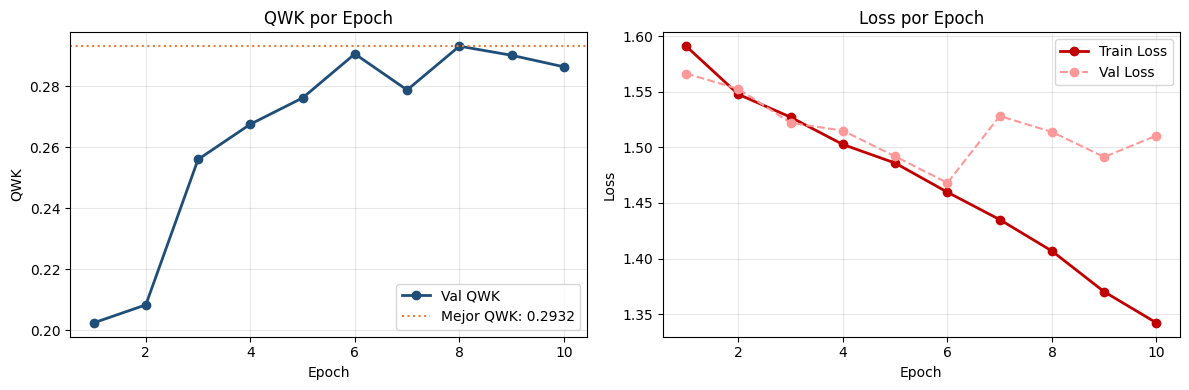

Curva guardada en: /content/drive/MyDrive/PETFINDER_GRUPO8_R10/Imagenes/work/resultados/learning_curve.png


In [27]:
# CELDA 13 — Curva de aprendizaje
history_path = RESULTS_DIR / 'training_history.json'

if 'history' not in dir() or not history:
    if history_path.exists():
        with open(history_path) as f:
            data = json.load(f)
        history    = data['history']
        best_kappa = data['best_kappa']
        print(f'Historial cargado desde disco.')
    else:
        print('Sin historial. Ejecuta primero la Celda 12.')
        history = None

if history:
    h = pd.DataFrame(history)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # ── QWK ──────────────────────────────────────────────────────────
    if 'train_kappa' in h.columns:
        ax1.plot(h['epoch'], h['train_kappa'], 'o--', color='#70AD47',
                 linewidth=1.5, label='Train QWK')
    ax1.plot(h['epoch'], h['kappa'], 'o-', color='#1F4E79',
             linewidth=2, label='Val QWK')
    ax1.axhline(best_kappa, linestyle=':', color='#ED7D31',
                label=f'Mejor QWK: {best_kappa:.4f}')
    ax1.set_title('QWK por Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('QWK')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # ── Loss ─────────────────────────────────────────────────────────
    ax2.plot(h['epoch'], h['loss'], 'o-', color='#C00000',
             linewidth=2, label='Train Loss')
    if 'val_loss' in h.columns:
        ax2.plot(h['epoch'], h['val_loss'], 'o--', color='#FF9999',
                 linewidth=1.5, label='Val Loss')
    ax2.set_title('Loss por Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    fig_path = RESULTS_DIR / 'learning_curve.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Curva guardada en: {fig_path}')

---
## Celda 14 — Etapa 6: Predicciones de validacion

Genera las predicciones del modelo sobre el set de validacion completo (2,931 registros) y las guarda en `work/optuna_artifacts/resnet_best_predictions.joblib`.

### Estructura del archivo generado

| Columna | Tipo | Descripcion |
|---------|------|-------------|
| `PetID` | string | Identificador del animal (para merge con LightGBM) |
| `pred` | list[float] | Logits crudos del modelo (vector de 5 valores, uno por clase) |
| `AdoptionSpeed` | int | Etiqueta real (ground truth) |

### Uso en el ensamble

Este archivo es consumido por `ensemble_resnet_lgb.py` que combina:
- ResNet50
- LightGBM
- Texto
- Ponderacion optima buscada por grid search sobre QWK de validacion

In [28]:
# CELDA 14 — ETAPA 6: Predicciones de validacion -> resnet_best_predictions.joblib
def guardar_predicciones_validacion(model, val_loader, val_pet_ids):
    model.eval()
    all_scores, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc='Prediciendo validacion'):
            outputs = model(inputs.to(DEVICE))
            all_scores.extend(outputs.cpu().numpy().tolist())
            all_labels.extend(labels.numpy().tolist())

    pred_df = pd.DataFrame({
        'PetID':         val_pet_ids,
        'pred':          all_scores,
        'AdoptionSpeed': all_labels,
    })

    output_path = ARTIFACTS_DIR / 'resnet_best_predictions.joblib'
    dump(pred_df, output_path)
    print(f'Predicciones guardadas: {output_path}')
    print(f'Shape: {pred_df.shape}')
    print(pred_df.head(3).to_string())
    return pred_df

print('\n' + '=' * 70)
print('ETAPA 6 - PREDICCIONES DE VALIDACION')
print('=' * 70)
pred_df = guardar_predicciones_validacion(model, val_loader, val_pet_ids)


ETAPA 6 - PREDICCIONES DE VALIDACION


Prediciendo validacion:   0%|          | 0/46 [00:00<?, ?it/s]

Predicciones guardadas: /content/drive/MyDrive/PETFINDER_GRUPO8_R10/Imagenes/work/optuna_artifacts/resnet_best_predictions.joblib
Shape: (2931, 3)
       PetID                                                                                                     pred  AdoptionSpeed
0  015da9e87  [1.1961698532104492, 0.3114126920700073, 0.03985978662967682, -0.8145412802696228, -0.9279671311378479]              0
1  022606901  [-1.8662093877792358, -0.2842012941837311, 0.38305893540382385, 0.9435345530509949, 0.7605675458908081]              0
2  02f89bdcb   [-1.100622296333313, -0.2071865200996399, -0.12952159345149994, 0.526155948638916, 0.7481365203857422]              0


---
## Celda 15 — Resumen final

Resumen de todos los artefactos generados por el pipeline con sus rutas absolutas en Drive y el tamano en disco. Estos archivos son los insumos para la etapa de ensamble con LightGBM.

In [31]:
# CELDA 15 — Resumen final
# Cargar best_kappa desde disco si la sesion se reinicio
if 'best_kappa' not in dir():
    history_path = RESULTS_DIR / 'training_history.json'
    if history_path.exists():
        with open(history_path) as f:
            best_kappa = json.load(f)['best_kappa']
    else:
        best_kappa = float('nan')

print('\n' + '=' * 70)
print('PIPELINE COMPLETADO')
print('=' * 70)
print(f'  QWK ResNet50 (validacion) : {best_kappa:.4f}')
print(f'  Modelo guardado           : {TEMP_DIR}/{MODEL_NAME}_final.pth')
print(f'  Predicciones              : {ARTIFACTS_DIR}/resnet_best_predictions.joblib')
print(f'  Resultados                : {RESULTS_DIR}')
print()
print('Archivos generados en Drive:')
for f in list(ARTIFACTS_DIR.glob('*.joblib')) + list(TEMP_DIR.glob('*.pth')) + list(RESULTS_DIR.glob('*.json')):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name}  ({size_mb:.1f} MB)')


PIPELINE COMPLETADO
  QWK ResNet50 (validacion) : 0.2932
  Modelo guardado           : /content/drive/MyDrive/PETFINDER_GRUPO8_R10/Imagenes/work/optuna_temp_artifacts/ResNet50_PetFinder_v2_final.pth
  Predicciones              : /content/drive/MyDrive/PETFINDER_GRUPO8_R10/Imagenes/work/optuna_artifacts/resnet_best_predictions.joblib
  Resultados                : /content/drive/MyDrive/PETFINDER_GRUPO8_R10/Imagenes/work/resultados

Archivos generados en Drive:
  resnet_best_predictions.joblib  (0.2 MB)
  ResNet50_PetFinder_v2_final.pth  (94.4 MB)
  training_history.json  (0.0 MB)


---
## Celda 16 — Verificacion de PetIDs para el ensamble

Verifica que los PetIDs del archivo `resnet_best_predictions.joblib` sean consistentes
con el split de validacion y compatibles con el merge que realiza el pipeline de ensamble.

El modelo tabular (LightGBM) genera predicciones para los 2,999 registros de validacion.
ResNet50 solo cubre las mascotas con imagen disponible. El ensamble hace un left join sobre
el val_split: los registros sin prediccion visual reciben peso 0 de ResNet50 y son cubiertos
unicamente por LightGBM y el modelo de texto.

In [30]:
# CELDA 16 — Verificacion de PetIDs para el ensamble
import joblib

print('=' * 70)
print('VERIFICACION DE PETIDS PARA EL ENSAMBLE')
print('=' * 70)

# Cargar predicciones ResNet50
preds = joblib.load(ARTIFACTS_DIR / 'resnet_best_predictions.joblib')
resnet_ids = set(preds['PetID'].values)

# Cargar val_split completo (referencia del ensamble)
val_split = pd.read_csv(WORK_DIR / 'val_split.csv')
val_ids   = set(val_split['PetID'].values)

# Metricas de cobertura
en_ambos      = resnet_ids & val_ids
solo_resnet   = resnet_ids - val_ids
solo_valsplit = val_ids - resnet_ids

print(f'\nRegistros en val_split (LightGBM cubre todos) : {len(val_ids):,}')
print(f'Registros en resnet_best_predictions.joblib   : {len(resnet_ids):,}')
print(f'\nPetIDs en ambos (van al merge)                : {len(en_ambos):,}')
print(f'PetIDs solo en ResNet50 (no estan en val_split): {len(solo_resnet):,}')
print(f'PetIDs solo en val_split (sin prediccion visual): {len(solo_valsplit):,}')

cobertura = len(en_ambos) / len(val_ids) * 100
print(f'\nCobertura visual en validacion: {cobertura:.1f}%')
print(f'  -> El {cobertura:.1f}% de los registros val tendra prediccion ResNet50 en el ensamble.')
print(f'  -> El {100 - cobertura:.1f}% restante sera cubierto solo por LightGBM y texto.')

# Verificar integridad del joblib
print(f'\nColumnas en joblib : {list(preds.columns)}')
print(f'Shape              : {preds.shape}')
print(f'Nulos en PetID     : {preds["PetID"].isna().sum()}')
print(f'PetIDs duplicados  : {preds["PetID"].duplicated().sum()}')

if len(solo_resnet) == 0 and preds['PetID'].duplicated().sum() == 0:
    print('\nOK: el archivo esta listo para el ensamble.')
else:
    if len(solo_resnet) > 0:
        print(f'\nATENCION: {len(solo_resnet)} PetIDs en ResNet no estan en val_split.')
    if preds['PetID'].duplicated().sum() > 0:
        print(f'\nATENCION: hay PetIDs duplicados en el joblib.')

VERIFICACION DE PETIDS PARA EL ENSAMBLE

Registros en val_split (LightGBM cubre todos) : 2,999
Registros en resnet_best_predictions.joblib   : 2,931

PetIDs en ambos (van al merge)                : 2,931
PetIDs solo en ResNet50 (no estan en val_split): 0
PetIDs solo en val_split (sin prediccion visual): 68

Cobertura visual en validacion: 97.7%
  -> El 97.7% de los registros val tendra prediccion ResNet50 en el ensamble.
  -> El 2.3% restante sera cubierto solo por LightGBM y texto.

Columnas en joblib : ['PetID', 'pred', 'AdoptionSpeed']
Shape              : (2931, 3)
Nulos en PetID     : 0
PetIDs duplicados  : 0

OK: el archivo esta listo para el ensamble.
